# Layer-2 count probes under single-head mean ablation

This notebook trains two multinomial logistic probes on the residual stream after zero-indexed transformer block 2 (`blocks.2.hook_resid_post`):

- **character count:** cumulative characters through the current content token; and
- **characters remaining:** the example's sampled line width minus that cumulative count (negative values are overshoots).

Both probes are trained once on clean activations. Their implied classifiers are evaluated on a separate fixed sample, first clean and then after independently mean-ablating each head in layer 2 at `blocks.2.attn.hook_z`. Accuracy is exact-class accuracy conditioned on each true label value. Count-zero BOS/newline positions are excluded from both tasks.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import project_main.checkpoints as project_checkpoints
import project_main.data as project_data
import project_main.model as project_model
import project_main.tokens as project_tokens

RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"
LAYER = 2
N_TRAIN_SEQUENCES = 2_000
N_MEAN_SEQUENCES = 2_048
N_EVAL_SEQUENCES = 2_000
BATCH_SIZE = 128
TRAIN_SEED = 14_001
MEAN_SEED = 14_002
EVAL_SEED = 14_003

In [2]:
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab = project_tokens.build_vocab(cfg["task"])
model = project_model.build_model(cfg=cfg, device=device)
checkpoint = project_checkpoints.load_checkpoint(
    path=CHECKPOINT_PATH, model=model, map_location=device
)
model.eval()

n_layers = cfg["model"]["n_layers"]
n_heads = cfg["model"]["n_heads"]
d_head = cfg["model"]["d_head"]
if not 0 <= LAYER < n_layers:
    raise ValueError(f"LAYER must be in [0, {n_layers - 1}].")

min_line_width, max_line_width = project_data.get_line_length_range(cfg["task"])
max_token_length = cfg["task"]["num_token_lengths"]
max_character_count = max_line_width + max_token_length - 1
min_characters_remaining = -(max_token_length - 1)
max_characters_remaining = max_line_width - 1
CHARACTER_COUNT_VALUES = np.arange(1, max_character_count + 1)
CHARACTERS_REMAINING_VALUES = np.arange(
    min_characters_remaining, max_characters_remaining + 1
)
RESIDUAL_SITE = f"blocks.{LAYER}.hook_resid_post"
ABLATION_SITE = f"blocks.{LAYER}.attn.hook_z"

print(f"Loaded checkpoint step {checkpoint['step']} on {device}")
print(f"Probe site: {RESIDUAL_SITE}")
print(f"Mean-ablation site: {ABLATION_SITE} ({n_heads} heads)")
print(f"Character counts: {CHARACTER_COUNT_VALUES[0]} through {CHARACTER_COUNT_VALUES[-1]}")
print(
    f"Characters remaining: {CHARACTERS_REMAINING_VALUES[0]} through "
    f"{CHARACTERS_REMAINING_VALUES[-1]}"
)

Building vocab...
('BOS', '_NEWLINE_')
Loaded checkpoint step 10000 on cpu
Probe site: blocks.2.hook_resid_post
Mean-ablation site: blocks.2.attn.hook_z (4 heads)
Character counts: 1 through 107
Characters remaining: -7 through 99


## Build aligned labels and collect clean training residuals

Labels are aligned to input-token residual positions. A content token adds its length before its label is recorded; a newline resets the running count to zero.

In [3]:
def count_labels_for_batch(
    token_rows: torch.Tensor, line_widths: torch.Tensor
) -> tuple[torch.Tensor, torch.Tensor]:
    """Return character-count and characters-remaining labels by position."""
    all_counts = []
    all_remaining = []
    for token_row, line_width in zip(
        token_rows.detach().cpu().tolist(),
        line_widths.detach().cpu().tolist(),
    ):
        running_count = 0
        row_counts = []
        row_remaining = []
        for token_id in token_row:
            if token_id == vocab.newline_id:
                running_count = 0
                row_counts.append(0)
                row_remaining.append(0)  # excluded by the count > 0 mask
            else:
                running_count += project_data.extract_character_count(
                    vocab.decode_token(token_id)
                )
                row_counts.append(running_count)
                row_remaining.append(line_width - running_count)
        all_counts.append(row_counts)
        all_remaining.append(row_remaining)
    return (
        torch.tensor(all_counts, dtype=torch.long),
        torch.tensor(all_remaining, dtype=torch.long),
    )


@torch.no_grad()
def collect_clean_probe_training_data(
    n_sequences: int, *, seed: int, batch_size: int = BATCH_SIZE
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    residual_chunks = []
    count_chunks = []
    remaining_chunks = []

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size, vocab=vocab, task_cfg=cfg["task"],
            device=device, seed=seed + start,
        )
        counts, remaining = count_labels_for_batch(
            batch.tokens, batch.line_lengths
        )
        saved = {}

        def save_residuals(residual, hook):
            saved["residuals"] = residual.detach().cpu()

        model.run_with_hooks(
            batch.tokens, prepend_bos=False,
            fwd_hooks=[(RESIDUAL_SITE, save_residuals)],
        )
        keep = counts > 0
        residual_chunks.append(saved["residuals"][keep].float().numpy())
        count_chunks.append(counts[keep].numpy())
        remaining_chunks.append(remaining[keep].numpy())

    return (
        np.concatenate(residual_chunks),
        np.concatenate(count_chunks),
        np.concatenate(remaining_chunks),
    )


X_train, y_count_train, y_remaining_train = collect_clean_probe_training_data(
    N_TRAIN_SEQUENCES, seed=TRAIN_SEED
)
for name, expected, observed in [
    ("character count", CHARACTER_COUNT_VALUES, y_count_train),
    ("characters remaining", CHARACTERS_REMAINING_VALUES, y_remaining_train),
]:
    missing = sorted(set(expected) - set(np.unique(observed)))
    if missing:
        raise RuntimeError(f"Training data is missing {name} classes {missing}.")

print("Training residuals:", X_train.shape)
print("Character-count classes:", len(np.unique(y_count_train)))
print("Characters-remaining classes:", len(np.unique(y_remaining_train)))

Training residuals: (282121, 128)
Character-count classes: 107
Characters-remaining classes: 107


## Fit the two clean multinomial probes

Each pipeline standardizes residual dimensions and fits a multinomial logistic classifier. These fitted pipelines remain unchanged during every ablated evaluation.

In [4]:
def fit_probe(X: np.ndarray, y: np.ndarray):
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=1.0, solver="lbfgs", max_iter=1_000, tol=1e-3
        ),
    ).fit(X, y)


character_count_probe = fit_probe(X_train, y_count_train)
characters_remaining_probe = fit_probe(X_train, y_remaining_train)

if not np.array_equal(
    character_count_probe.named_steps["logisticregression"].classes_,
    CHARACTER_COUNT_VALUES,
):
    raise RuntimeError("Unexpected character-count probe classes.")
if not np.array_equal(
    characters_remaining_probe.named_steps["logisticregression"].classes_,
    CHARACTERS_REMAINING_VALUES,
):
    raise RuntimeError("Unexpected characters-remaining probe classes.")

print("Fitted character-count probe classes:", len(CHARACTER_COUNT_VALUES))
print("Fitted characters-remaining probe classes:", len(CHARACTERS_REMAINING_VALUES))

Fitted character-count probe classes: 107
Fitted characters-remaining probe classes: 107


## Estimate the layer-2 head means

Each head's `hook_z` replacement vector is its global mean over every position in a separate calibration sample.

In [5]:
@torch.no_grad()
def estimate_layer_head_means(
    n_sequences: int, *, seed: int, batch_size: int = BATCH_SIZE
) -> torch.Tensor:
    head_sum = torch.zeros(n_heads, d_head, dtype=torch.float64)
    n_vectors = 0
    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size, vocab=vocab, task_cfg=cfg["task"],
            device=device, seed=seed + start,
        )
        saved = {}

        def save_z(z, hook):
            saved["z"] = z.detach().cpu()

        model.run_with_hooks(
            batch.tokens, prepend_bos=False,
            fwd_hooks=[(ABLATION_SITE, save_z)],
        )
        z = saved["z"].double()
        head_sum += z.sum(dim=(0, 1))
        n_vectors += z.shape[0] * z.shape[1]
    return (head_sum / n_vectors).float()


mean_head_outputs = estimate_layer_head_means(
    N_MEAN_SEQUENCES, seed=MEAN_SEED
)
assert mean_head_outputs.shape == (n_heads, d_head)
print("Mean head-output norms:")
display(
    pd.Series(
        mean_head_outputs.norm(dim=-1).numpy(),
        index=[f"L{LAYER}H{head}" for head in range(n_heads)],
        name="mean_z_norm",
    ).to_frame()
)

Mean head-output norms:


,mean_z_norm
L2H0,3.115882
L2H1,7.925813
L2H2,2.769212
L2H3,5.054648


## Evaluate clean and single-head-ablated residuals

All conditions reuse identical evaluation examples. Per-class numerators and denominators are accumulated across the full sample before division.

In [6]:
@torch.no_grad()
def evaluate_condition(
    ablate_head: int | None = None,
    *,
    n_sequences: int = N_EVAL_SEQUENCES,
    seed: int = EVAL_SEED,
    batch_size: int = BATCH_SIZE,
) -> dict[str, np.ndarray | float]:
    count_correct = np.zeros(len(CHARACTER_COUNT_VALUES), dtype=np.int64)
    count_total = np.zeros(len(CHARACTER_COUNT_VALUES), dtype=np.int64)
    remaining_correct = np.zeros(
        len(CHARACTERS_REMAINING_VALUES), dtype=np.int64
    )
    remaining_total = np.zeros(
        len(CHARACTERS_REMAINING_VALUES), dtype=np.int64
    )

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size, vocab=vocab, task_cfg=cfg["task"],
            device=device, seed=seed + start,
        )
        counts, remaining = count_labels_for_batch(
            batch.tokens, batch.line_lengths
        )
        saved = {}
        fwd_hooks = []

        if ablate_head is not None:
            replacement = mean_head_outputs[ablate_head]

            def mean_ablate_head(z, hook):
                ablated = z.clone()
                ablated[:, :, ablate_head, :] = replacement.to(
                    device=z.device, dtype=z.dtype
                )
                return ablated

            fwd_hooks.append((ABLATION_SITE, mean_ablate_head))

        def save_residuals(residual, hook):
            saved["residuals"] = residual.detach().cpu()

        fwd_hooks.append((RESIDUAL_SITE, save_residuals))
        model.run_with_hooks(
            batch.tokens, prepend_bos=False, fwd_hooks=fwd_hooks
        )

        keep = counts > 0
        X_batch = saved["residuals"][keep].float().numpy()
        y_count = counts[keep].numpy()
        y_remaining = remaining[keep].numpy()
        predicted_count = character_count_probe.predict(X_batch)
        predicted_remaining = characters_remaining_probe.predict(X_batch)

        count_indices = y_count - CHARACTER_COUNT_VALUES[0]
        remaining_indices = y_remaining - CHARACTERS_REMAINING_VALUES[0]
        np.add.at(count_total, count_indices, 1)
        np.add.at(count_correct, count_indices, predicted_count == y_count)
        np.add.at(remaining_total, remaining_indices, 1)
        np.add.at(
            remaining_correct, remaining_indices,
            predicted_remaining == y_remaining,
        )

    if np.any(count_total == 0) or np.any(remaining_total == 0):
        raise RuntimeError("Evaluation sample is missing at least one label class.")
    return {
        "count_accuracy": count_correct / count_total,
        "count_examples": count_total,
        "count_overall_accuracy": count_correct.sum() / count_total.sum(),
        "remaining_accuracy": remaining_correct / remaining_total,
        "remaining_examples": remaining_total,
        "remaining_overall_accuracy": (
            remaining_correct.sum() / remaining_total.sum()
        ),
    }


condition_results = {"clean": evaluate_condition()}
for head in range(n_heads):
    name = f"mean_ablate_L{LAYER}H{head}"
    condition_results[name] = evaluate_condition(ablate_head=head)
    result = condition_results[name]
    print(
        f"{name}: count={result['count_overall_accuracy']:.2%}, "
        f"remaining={result['remaining_overall_accuracy']:.2%}"
    )

print(
    f"clean: count={condition_results['clean']['count_overall_accuracy']:.2%}, "
    f"remaining={condition_results['clean']['remaining_overall_accuracy']:.2%}"
)

mean_ablate_L2H0: count=23.65%, remaining=18.37%


mean_ablate_L2H1: count=19.06%, remaining=11.60%


mean_ablate_L2H2: count=21.94%, remaining=11.09%


mean_ablate_L2H3: count=24.01%, remaining=14.05%
clean: count=26.81%, remaining=20.50%


## Overall exact-class accuracy

These overall values weight each position equally. The following sections display the requested accuracies conditioned on every true value.

In [7]:
overall_results = pd.DataFrame(
    {
        condition: {
            "character_count_accuracy": result["count_overall_accuracy"],
            "characters_remaining_accuracy": result["remaining_overall_accuracy"],
        }
        for condition, result in condition_results.items()
    }
).T
display(overall_results.style.format("{:.2%}"))

,character_count_accuracy,characters_remaining_accuracy
clean,26.81%,20.50%
mean_ablate_L2H0,23.65%,18.37%
mean_ablate_L2H1,19.06%,11.60%
mean_ablate_L2H2,21.94%,11.09%
mean_ablate_L2H3,24.01%,14.05%


## Character-count accuracy conditioned on true character count

,n_examples,clean,mean_ablate_L2H0,mean_ablate_L2H1,mean_ablate_L2H2,mean_ablate_L2H3
true_value,,,,,,
1,2191,92.88%,88.50%,73.16%,78.00%,96.81%
2,2393,70.96%,63.64%,77.73%,50.06%,43.71%
3,2873,60.15%,49.46%,45.28%,41.59%,41.42%
4,3146,51.37%,44.47%,53.50%,32.04%,32.10%
5,3512,50.03%,46.84%,45.36%,43.74%,62.07%
6,4006,44.83%,45.88%,14.68%,46.68%,51.62%
7,4517,46.07%,41.04%,52.03%,32.26%,40.38%
8,5124,48.75%,46.17%,25.00%,38.95%,39.64%
9,3423,21.30%,13.53%,20.83%,15.48%,28.19%


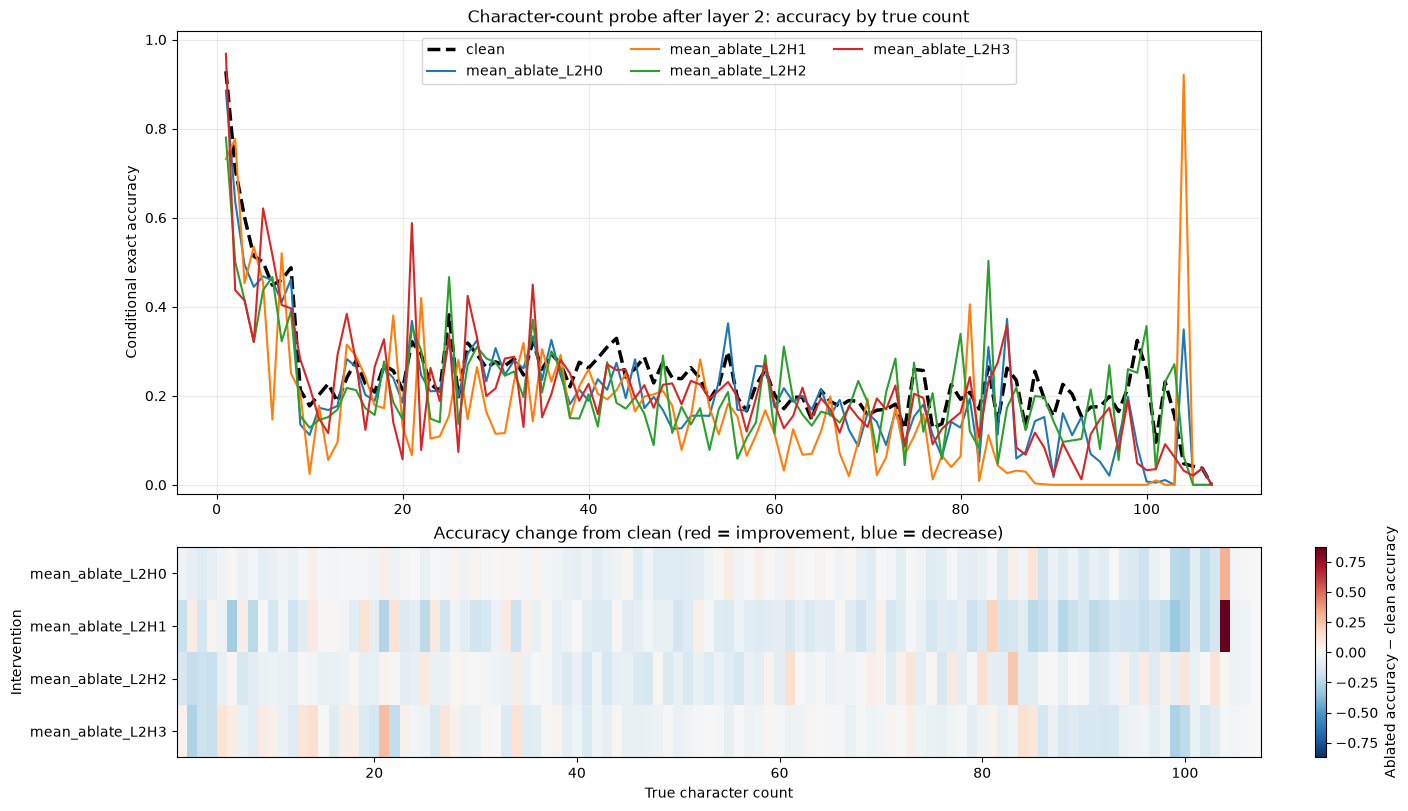

In [8]:
def conditional_accuracy_table(
    values: np.ndarray, accuracy_key: str, examples_key: str
) -> pd.DataFrame:
    table = pd.DataFrame({"true_value": values})
    table["n_examples"] = condition_results["clean"][examples_key]
    for condition, result in condition_results.items():
        table[condition] = result[accuracy_key]
    return table.set_index("true_value")


def plot_conditional_accuracies(
    table: pd.DataFrame, *, title: str, x_label: str
) -> None:
    condition_columns = [c for c in table.columns if c != "n_examples"]
    ablation_columns = [c for c in condition_columns if c != "clean"]
    fig, axes = plt.subplots(
        2, 1, figsize=(14, 8), constrained_layout=True,
        gridspec_kw={"height_ratios": [2.2, 1]},
    )

    axes[0].plot(
        table.index, table["clean"], color="black", linewidth=2.5,
        linestyle="--", label="clean",
    )
    for column in ablation_columns:
        axes[0].plot(table.index, table[column], linewidth=1.5, label=column)
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].set_ylabel("Conditional exact accuracy")
    axes[0].set_title(title)
    axes[0].grid(alpha=0.25)
    axes[0].legend(ncol=3)

    deltas = np.vstack([
        table[column].to_numpy() - table["clean"].to_numpy()
        for column in ablation_columns
    ])
    limit = max(float(np.abs(deltas).max()), 1e-6)
    image = axes[1].imshow(
        deltas, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto",
        origin="upper", extent=(
            table.index.min() - 0.5, table.index.max() + 0.5,
            len(ablation_columns) - 0.5, -0.5,
        ),
    )
    axes[1].set_yticks(range(len(ablation_columns)), labels=ablation_columns)
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel("Intervention")
    axes[1].set_title("Accuracy change from clean (red = improvement, blue = decrease)")
    fig.colorbar(image, ax=axes[1], label="Ablated accuracy − clean accuracy")
    plt.show()


character_count_table = conditional_accuracy_table(
    CHARACTER_COUNT_VALUES, "count_accuracy", "count_examples"
)
display(
    character_count_table.style.format(
        {column: "{:.2%}" for column in character_count_table.columns if column != "n_examples"}
    )
)
plot_conditional_accuracies(
    character_count_table,
    title=f"Character-count probe after layer {LAYER}: accuracy by true count",
    x_label="True character count",
)

## Characters-remaining accuracy conditioned on true characters remaining

,n_examples,clean,mean_ablate_L2H0,mean_ablate_L2H1,mean_ablate_L2H2,mean_ablate_L2H3
true_value,,,,,,
-7,473,51.37%,56.24%,0.00%,4.86%,28.12%
-6,867,40.83%,40.72%,22.38%,5.88%,7.50%
-5,1371,39.97%,31.95%,7.22%,8.39%,13.57%
-4,1691,42.16%,33.65%,7.21%,23.30%,15.85%
-3,2194,38.61%,33.00%,0.14%,28.17%,5.61%
-2,2726,46.99%,42.08%,0.18%,31.88%,8.40%
-1,3163,50.65%,41.32%,0.22%,27.32%,9.39%
0,3551,49.28%,33.96%,0.20%,21.77%,7.86%
1,3562,47.67%,25.04%,0.20%,24.03%,6.79%


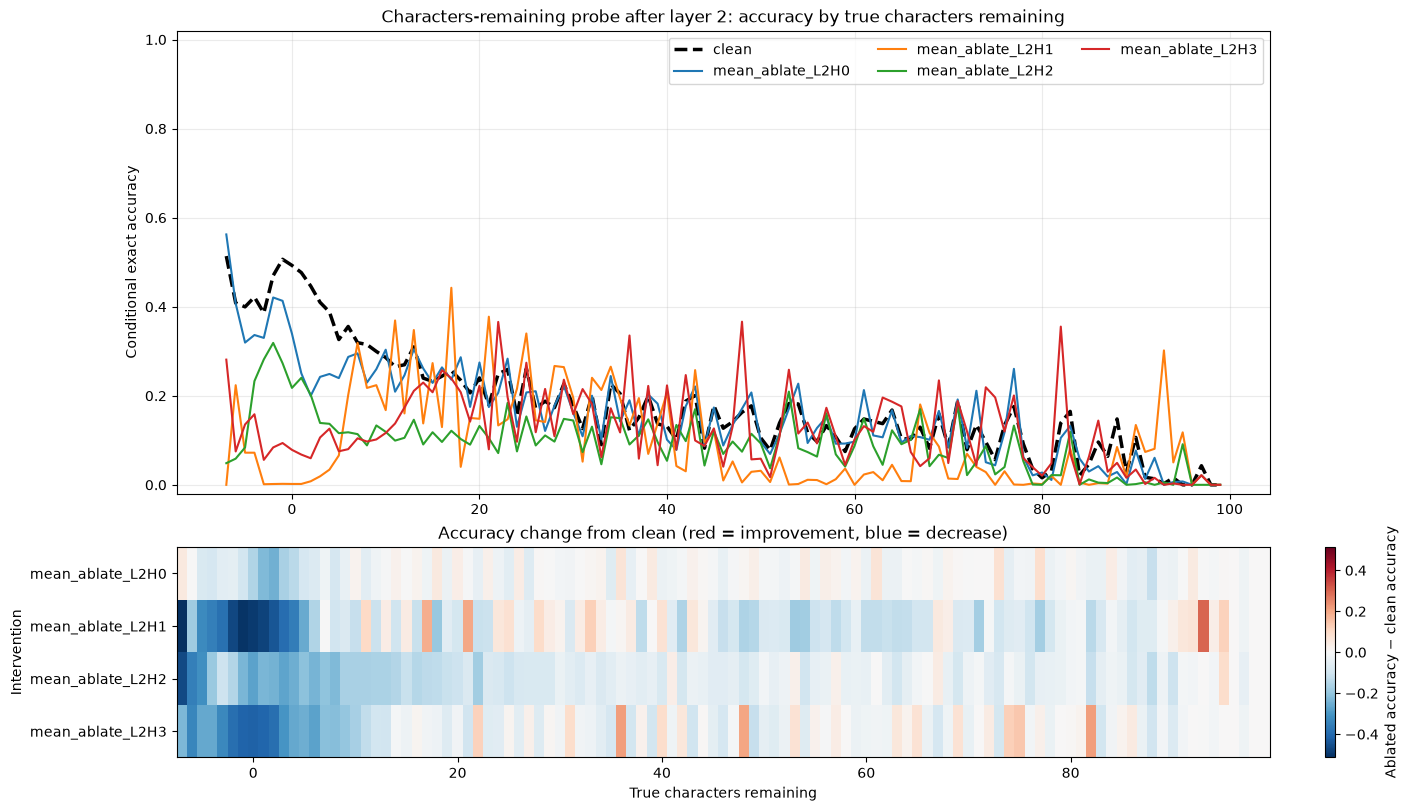

In [9]:
characters_remaining_table = conditional_accuracy_table(
    CHARACTERS_REMAINING_VALUES, "remaining_accuracy", "remaining_examples"
)
display(
    characters_remaining_table.style.format(
        {column: "{:.2%}" for column in characters_remaining_table.columns if column != "n_examples"}
    )
)
plot_conditional_accuracies(
    characters_remaining_table,
    title=(
        f"Characters-remaining probe after layer {LAYER}: "
        "accuracy by true characters remaining"
    ),
    x_label="True characters remaining",
)